# 🚨 Ransomware Detection ML Analysis

This Jupyter notebook provides comprehensive analysis and experimentation with the Ransomware Detection ML models.

## Contents
1. **Data Loading & Exploration**
2. **Data Preprocessing**
3. **Model Training** (Random Forest, SVM, Neural Networks)
4. **Model Evaluation & Comparison**
5. **Feature Importance Analysis**
6. **Visualizations**
7. **Predictions & Testing**


## 1. Import Libraries


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.inspection import permutation_importance

# Optional TensorFlow
try:
    import tensorflow as tf
    from tensorflow import keras
    TF_AVAILABLE = True
    print("✅ TensorFlow available")
except:
    TF_AVAILABLE = False
    print("⚠️ TensorFlow not available (optional for Neural Networks)")

# Kaggle dataset loading
try:
    import kagglehub
    from kagglehub import KaggleDatasetAdapter
    KAGGLE_AVAILABLE = True
    print("✅ Kagglehub available")
except:
    KAGGLE_AVAILABLE = False
    print("⚠️ Kagglehub not available (will use local file)")

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("\n📊 All libraries loaded successfully!\n")


⚠️ TensorFlow not available (optional for Neural Networks)
⚠️ Kagglehub not available (will use local file)

📊 All libraries loaded successfully!



## 2. Load Dataset


In [2]:
def load_dataset(file_path="data_file.csv"):
    """Load dataset from local file or Kaggle"""
    if os.path.exists(file_path):
        print(f"📁 Loading dataset from local file: {file_path}")
        df = pd.read_csv(file_path)
    elif KAGGLE_AVAILABLE:
        print(f"🌐 Loading dataset from Kaggle via kagglehub...")
        df = kagglehub.load_dataset(
            KaggleDatasetAdapter.PANDAS,
            "amdj3dax/ransomware-detection-data-set",
            file_path,
        )
    else:
        raise FileNotFoundError(
            f"Dataset file '{file_path}' not found. "
            "Please place data_file.csv in the project directory."
        )
    
    print(f"✅ Dataset loaded: {len(df)} rows, {len(df.columns)} columns")
    return df

# Load the dataset
df_raw = load_dataset()
print(f"\nDataset shape: {df_raw.shape}")
print(f"\nFirst few rows:")
df_raw.head()


📁 Loading dataset from local file: data_file.csv
✅ Dataset loaded: 62485 rows, 18 columns

Dataset shape: (62485, 18)

First few rows:


,FileName,md5Hash,Machine,DebugSize,DebugRVA,MajorImageVersion,MajorOSVersion,ExportRVA,ExportSize,IatVRA,MajorLinkerVersion,MinorLinkerVersion,NumberOfSections,SizeOfStackReserve,DllCharacteristics,ResourceSize,BitcoinAddresses,Benign
0,0124e21d-018c-4ce0-92a3-b9e205a76bc0.dll,79755c51e413ed3c6be4635fd729a6e1,332,0,0,0,4,0,0,8192,8,0,3,1048576,34112,672,0,1
1,05c8318f98a5d301d80000009c316005.vertdll.dll,95e19f3657d34a432eada93221b0ea16,34404,84,121728,10,10,126576,4930,0,14,10,8,262144,16864,1024,0,1
2,06054fba-5619-4a86-a861-ffb0464bef5d.dll,85c32641d77a54e19ba8ea4ab305c791,332,0,0,0,4,0,0,8192,8,0,3,1048576,34112,672,0,1
3,075822ac99a5d301660400009c316005.adhapi.dll,62e3b959d982ef534b66f819fe15f085,34404,84,19904,10,10,21312,252,18160,14,10,6,262144,16736,1040,0,1
4,090607dd9ba5d301ca0900009c316005.SensorsNative...,ae38c5f7d313ad0ff3bfb8826476767f,34404,84,97728,10,10,105792,1852,70592,14,10,7,262144,16736,1096,0,1


## 3. Data Exploration


In [3]:
print("📊 Dataset Info:")
print("=" * 50)
print(df_raw.info())
print("\n" + "=" * 50)
print("\n📈 Basic Statistics:")
df_raw.describe()


📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62485 entries, 0 to 62484
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   FileName            62485 non-null  object
 1   md5Hash             62485 non-null  object
 2   Machine             62485 non-null  int64 
 3   DebugSize           62485 non-null  int64 
 4   DebugRVA            62485 non-null  int64 
 5   MajorImageVersion   62485 non-null  int64 
 6   MajorOSVersion      62485 non-null  int64 
 7   ExportRVA           62485 non-null  int64 
 8   ExportSize          62485 non-null  int64 
 9   IatVRA              62485 non-null  int64 
 10  MajorLinkerVersion  62485 non-null  int64 
 11  MinorLinkerVersion  62485 non-null  int64 
 12  NumberOfSections    62485 non-null  int64 
 13  SizeOfStackReserve  62485 non-null  int64 
 14  DllCharacteristics  62485 non-null  int64 
 15  ResourceSize        62485 non-null  int64 
 16  Bitcoi

,Machine,DebugSize,DebugRVA,MajorImageVersion,MajorOSVersion,ExportRVA,ExportSize,IatVRA,MajorLinkerVersion,MinorLinkerVersion,NumberOfSections,SizeOfStackReserve,DllCharacteristics,ResourceSize,BitcoinAddresses,Benign
count,62485.000000,6.248500e+04,6.248500e+04,62485.000000,62485.000000,6.248500e+04,6.248500e+04,6.248500e+04,62485.000000,62485.000000,62485.000000,6.248500e+04,62485.000000,6.248500e+04,62485.000000,62485.000000
mean,6756.472657,2.587048e+04,1.541611e+05,58.785997,5.417524,8.953186e+05,4.094623e+05,1.466311e+05,9.782604,6.613171,4.751172,8.759830e+05,12966.031400,1.844664e+05,0.018004,0.433992
std,13345.499919,6.461396e+06,1.903142e+06,1114.068244,2.543697,3.779527e+07,2.851820e+07,1.124630e+06,9.047157,16.976465,2.138584,6.288189e+05,15762.725511,1.732625e+07,0.132968,0.495628
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
25%,332.000000,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000e+00,0.000000e+00,4.096000e+03,6.000000,0.000000,3.000000,2.621440e+05,0.000000,1.080000e+03,0.000000,0.000000
50%,332.000000,0.000000e+00,0.000000e+00,0.000000,5.000000,0.000000e+00,0.000000e+00,8.520000e+03,9.000000,0.000000,5.000000,1.048576e+06,320.000000,2.496000e+03,0.000000,0.000000
75%,332.000000,2.800000e+01,1.283200e+04,6.000000,6.000000,2.875200e+04,1.040000e+02,6.553600e+04,11.000000,10.000000,6.000000,1.048576e+06,32768.000000,2.350400e+04,0.000000,1.000000
max,43620.000000,1.615155e+09,2.852127e+08,63325.000000,260.000000,2.147484e+09,2.415919e+09,6.615450e+07,255.000000,255.000000,33.000000,1.677722e+07,58632.000000,4.294942e+09,1.000000,1.000000


🔍 Missing Values:
✅ No missing values found!

🎯 Label Distribution:
Benign (1): 27118 samples
Malicious (0): 35367 samples


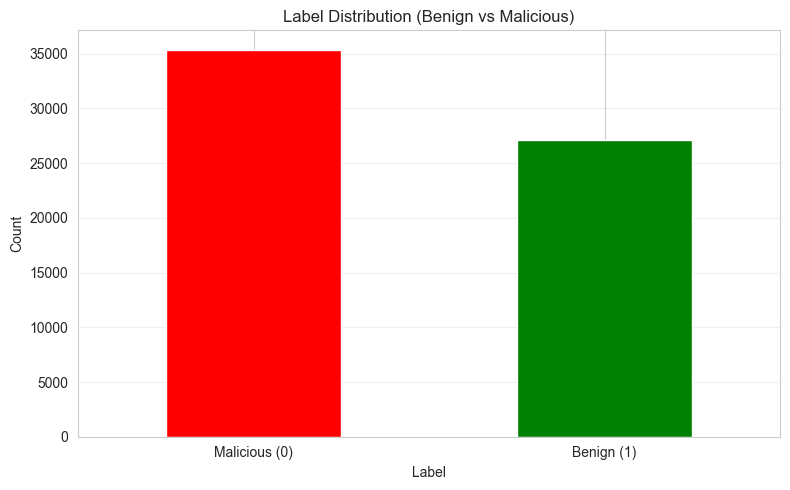

In [4]:
# Check for missing values
print("🔍 Missing Values:")
missing = df_raw.isnull().sum()
missing_percent = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df)
else:
    print("✅ No missing values found!")

# Check label distribution
if 'Benign' in df_raw.columns:
    print("\n🎯 Label Distribution:")
    label_counts = df_raw['Benign'].value_counts()
    print(f"Benign (1): {label_counts.get(1, 0)} samples")
    print(f"Malicious (0): {label_counts.get(0, 0)} samples")
    
    # Visualize label distribution
    plt.figure(figsize=(8, 5))
    label_counts.plot(kind='bar', color=['red', 'green'])
    plt.title('Label Distribution (Benign vs Malicious)')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.xticks([0, 1], ['Malicious (0)', 'Benign (1)'], rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


## 4. Data Preprocessing


In [5]:
def preprocess_data(df):
    """Preprocess the dataset"""
    print("🔧 Preprocessing data...")
    
    # Drop identifier columns
    drop_cols = [c for c in ['FileName', 'md5Hash'] if c in df.columns]
    if drop_cols:
        df = df.drop(columns=drop_cols, errors='ignore')
        print(f"  ✓ Dropped identifier columns: {drop_cols}")
    
    # Replace inf with NaN and drop
    df = df.replace([np.inf, -np.inf], np.nan)
    initial_rows = len(df)
    df = df.dropna(axis=0)
    dropped_rows = initial_rows - len(df)
    if dropped_rows > 0:
        print(f"  ✓ Dropped {dropped_rows} rows with NaN/inf values")
    
    # Ensure Benign column exists
    if 'Benign' not in df.columns:
        raise ValueError("Dataset missing 'Benign' label column")
    
    # Create ransomware label (1=ransomware, 0=benign)
    df = df.copy()
    df['ransomware'] = 1 - df['Benign'].astype(int)
    
    # Select numeric features only
    numeric_df = df.select_dtypes(include=[np.number])
    feature_columns = [c for c in numeric_df.columns if c not in ['Benign', 'ransomware']]
    
    # Keep only features + target
    processed_df = numeric_df[feature_columns + ['ransomware']]
    
    print(f"✅ Preprocessing complete!")
    print(f"  • {len(processed_df)} samples")
    print(f"  • {len(feature_columns)} features")
    
    return processed_df, feature_columns

# Preprocess the data
df_processed, feature_columns = preprocess_data(df_raw)
print(f"\n📋 Feature columns ({len(feature_columns)}):")
print(feature_columns[:10], "..." if len(feature_columns) > 10 else "")


🔧 Preprocessing data...
  ✓ Dropped identifier columns: ['FileName', 'md5Hash']
✅ Preprocessing complete!
  • 62485 samples
  • 15 features

📋 Feature columns (15):
['Machine', 'DebugSize', 'DebugRVA', 'MajorImageVersion', 'MajorOSVersion', 'ExportRVA', 'ExportSize', 'IatVRA', 'MajorLinkerVersion', 'MinorLinkerVersion'] ...


## 5. Prepare Training Data


In [6]:
# Split into features and target
X = df_processed[feature_columns]
y = df_processed['ransomware']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Train/Test Split:")
print(f"  • Training set: {len(X_train)} samples")
print(f"  • Test set: {len(X_test)} samples")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Features scaled using StandardScaler")


Features shape: (62485, 15)
Target shape: (62485,)

Target distribution:
ransomware
1    35367
0    27118
Name: count, dtype: int64

Target percentage:
ransomware
1    56.600784
0    43.399216
Name: proportion, dtype: float64

✅ Train/Test Split:
  • Training set: 49988 samples
  • Test set: 12497 samples
✅ Features scaled using StandardScaler


## 6. Train Models

### 6.1 Random Forest Classifier


In [7]:
print("🌲 Training Random Forest Classifier...")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample',
)

rf_model.fit(X_train_scaled, y_train)
rf_time = time.time() - start_time

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, zero_division=0)

print(f"✅ Random Forest training complete in {rf_time:.2f} seconds")
print(f"\n📊 Performance Metrics:")
print(f"  • Accuracy:  {rf_accuracy:.4f}")
print(f"  • Precision: {rf_precision:.4f}")
print(f"  • Recall:    {rf_recall:.4f}")
print(f"  • F1-Score:  {rf_f1:.4f}")


🌲 Training Random Forest Classifier...
✅ Random Forest training complete in 3.12 seconds

📊 Performance Metrics:
  • Accuracy:  0.9964
  • Precision: 0.9960
  • Recall:    0.9976
  • F1-Score:  0.9968


### 6.2 Support Vector Machine (SVM)


In [8]:
print("🔺 Training Support Vector Machine...")
start_time = time.time()

svm_model = SVC(
    kernel='rbf',
    C=2.0,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
svm_time = time.time() - start_time

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, zero_division=0)
svm_recall = recall_score(y_test, y_pred_svm, zero_division=0)
svm_f1 = f1_score(y_test, y_pred_svm, zero_division=0)

print(f"✅ SVM training complete in {svm_time:.2f} seconds")
print(f"\n📊 Performance Metrics:")
print(f"  • Accuracy:  {svm_accuracy:.4f}")
print(f"  • Precision: {svm_precision:.4f}")
print(f"  • Recall:    {svm_recall:.4f}")
print(f"  • F1-Score:  {svm_f1:.4f}")


🔺 Training Support Vector Machine...
✅ SVM training complete in 112.50 seconds

📊 Performance Metrics:
  • Accuracy:  0.9702
  • Precision: 0.9639
  • Recall:    0.9842
  • F1-Score:  0.9739


### 6.3 Neural Network (MLP)


In [9]:
print("🧠 Training Neural Network (MLP)...")
start_time = time.time()

if TF_AVAILABLE:
    # Use Keras/TensorFlow MLP
    try:
        nn_model = keras.Sequential([
            keras.layers.Input(shape=(X_train_scaled.shape[1],)),
            keras.layers.Dense(128, activation='relu'),
            keras.layers.Dropout(0.2),
            keras.layers.Dense(64, activation='relu'),
            keras.layers.Dropout(0.2),
            keras.layers.Dense(1, activation='sigmoid'),
        ])
        
        nn_model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        
        nn_model.fit(
            X_train_scaled, y_train,
            epochs=10,
            batch_size=256,
            verbose=0,
            validation_split=0.1
        )
        
        # Predictions (Keras)
        y_pred_proba_nn = nn_model.predict(X_test_scaled, verbose=0).reshape(-1)
        y_pred_nn = (y_pred_proba_nn >= 0.5).astype(int)
        
        use_keras = True
        print("  ✓ Using TensorFlow/Keras")
    except Exception as e:
        print(f"  ⚠️ Keras failed: {e}")
        use_keras = False
else:
    use_keras = False

if not use_keras:
    # Use scikit-learn MLP
    nn_model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        batch_size=256,
        max_iter=100,
        random_state=42
    )
    
    nn_model.fit(X_train_scaled, y_train)
    
    # Predictions (scikit-learn)
    y_pred_nn = nn_model.predict(X_test_scaled)
    y_pred_proba_nn = nn_model.predict_proba(X_test_scaled)[:, 1]
    print("  ✓ Using scikit-learn MLP")

nn_time = time.time() - start_time

# Metrics
nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_precision = precision_score(y_test, y_pred_nn, zero_division=0)
nn_recall = recall_score(y_test, y_pred_nn, zero_division=0)
nn_f1 = f1_score(y_test, y_pred_nn, zero_division=0)

print(f"✅ Neural Network training complete in {nn_time:.2f} seconds")
print(f"\n📊 Performance Metrics:")
print(f"  • Accuracy:  {nn_accuracy:.4f}")
print(f"  • Precision: {nn_precision:.4f}")
print(f"  • Recall:    {nn_recall:.4f}")
print(f"  • F1-Score:  {nn_f1:.4f}")


🧠 Training Neural Network (MLP)...
  ✓ Using scikit-learn MLP
✅ Neural Network training complete in 65.77 seconds

📊 Performance Metrics:
  • Accuracy:  0.9909
  • Precision: 0.9932
  • Recall:    0.9907
  • F1-Score:  0.9919


📊 Model Comparison:
         Model  Accuracy  Precision   Recall  F1-Score  Training Time (s)
 Random Forest  0.996399   0.996047 0.997596  0.996821           3.116354
           SVM  0.970153   0.963860 0.984165  0.973907         112.499769
Neural Network  0.990878   0.993196 0.990669  0.991931          65.768378


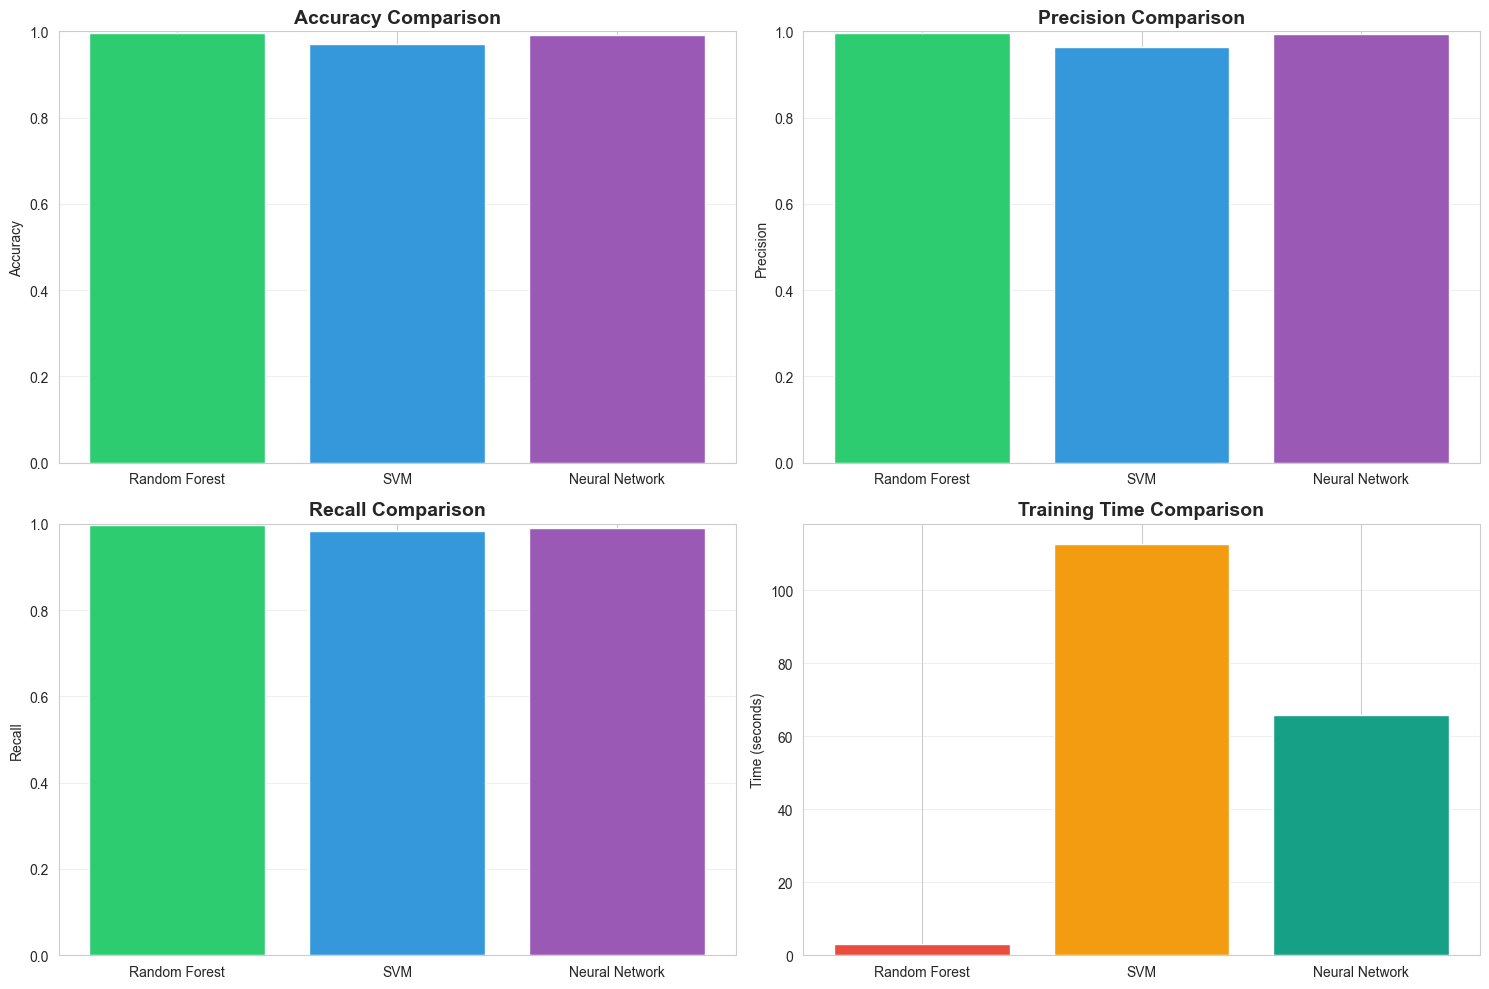


🏆 Best Model (by F1-Score): Random Forest


In [10]:
# Compare all models
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'Neural Network'],
    'Accuracy': [rf_accuracy, svm_accuracy, nn_accuracy],
    'Precision': [rf_precision, svm_precision, nn_precision],
    'Recall': [rf_recall, svm_recall, nn_recall],
    'F1-Score': [rf_f1, svm_f1, nn_f1],
    'Training Time (s)': [rf_time, svm_time, nn_time]
})

print("📊 Model Comparison:")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy comparison
axes[0, 0].bar(comparison_df['Model'], comparison_df['Accuracy'], color=['#2ecc71', '#3498db', '#9b59b6'])
axes[0, 0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)

# Precision comparison
axes[0, 1].bar(comparison_df['Model'], comparison_df['Precision'], color=['#2ecc71', '#3498db', '#9b59b6'])
axes[0, 1].set_title('Precision Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

# Recall comparison
axes[1, 0].bar(comparison_df['Model'], comparison_df['Recall'], color=['#2ecc71', '#3498db', '#9b59b6'])
axes[1, 0].set_title('Recall Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)

# Training time comparison
axes[1, 1].bar(comparison_df['Model'], comparison_df['Training Time (s)'], color=['#e74c3c', '#f39c12', '#16a085'])
axes[1, 1].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Time (seconds)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Find best model
best_model_idx = comparison_df['F1-Score'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Model']
print(f"\n🏆 Best Model (by F1-Score): {best_model}")


## 8. Confusion Matrices


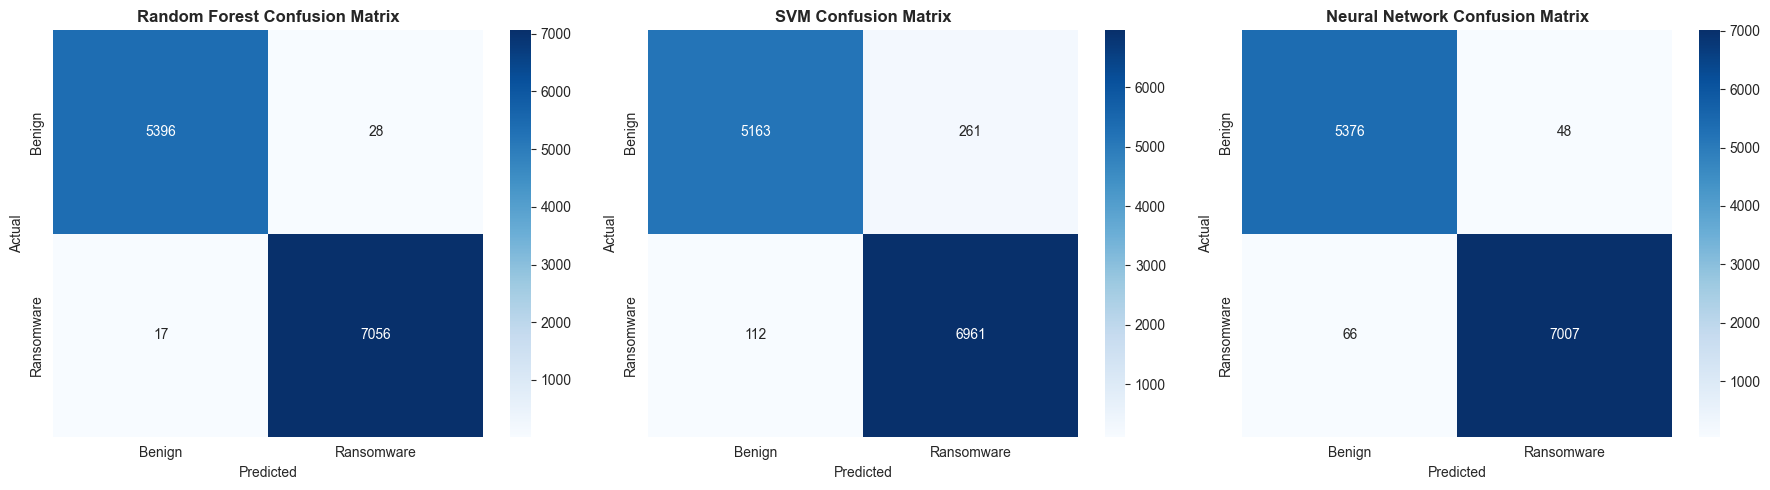

In [11]:
# Create confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ('Random Forest', y_pred_rf),
    ('SVM', y_pred_svm),
    ('Neural Network', y_pred_nn)
]

for idx, (model_name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        ax=axes[idx],
        xticklabels=['Benign', 'Ransomware'],
        yticklabels=['Benign', 'Ransomware']
    )
    axes[idx].set_title(f'{model_name} Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()


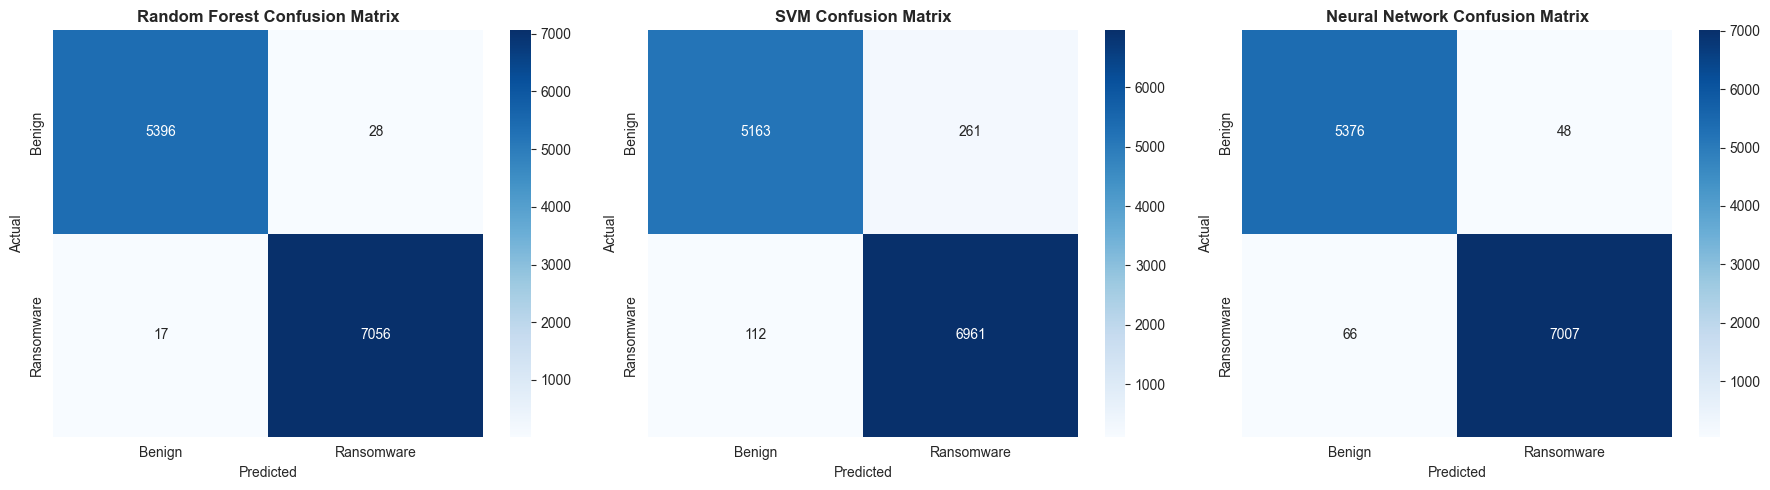

In [12]:
# Create confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ('Random Forest', y_pred_rf),
    ('SVM', y_pred_svm),
    ('Neural Network', y_pred_nn)
]

for idx, (model_name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        ax=axes[idx],
        xticklabels=['Benign', 'Ransomware'],
        yticklabels=['Benign', 'Ransomware']
    )
    axes[idx].set_title(f'{model_name} Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 9. Feature Importance Analysis


🌲 Top 20 Important Features (Random Forest):
           feature  importance
DllCharacteristics    0.235617
MajorLinkerVersion    0.125882
         DebugSize    0.115003
          DebugRVA    0.109270
      ResourceSize    0.085196
    MajorOSVersion    0.081489
  NumberOfSections    0.047942
           Machine    0.044942
SizeOfStackReserve    0.044352
            IatVRA    0.042532
 MajorImageVersion    0.025173
        ExportSize    0.016686
MinorLinkerVersion    0.014227
         ExportRVA    0.011015
  BitcoinAddresses    0.000675


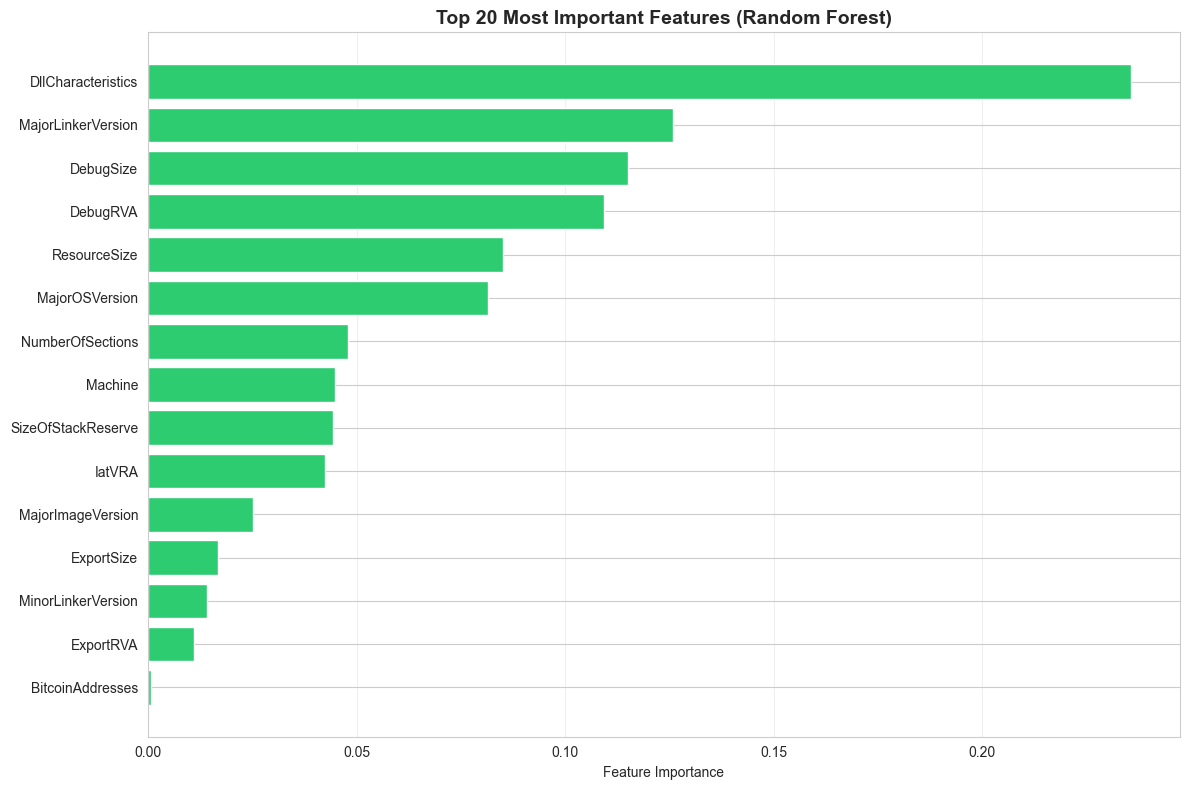

In [13]:
# Random Forest Feature Importance
rf_feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("🌲 Top 20 Important Features (Random Forest):")
print(rf_feature_importance.head(20).to_string(index=False))

# Visualize top features
plt.figure(figsize=(12, 8))
top_features = rf_feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'], color='#2ecc71')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


🔺 Calculating Permutation Importance for SVM (this may take a minute)...
✅ Permutation importance calculated in 254.05 seconds

🔺 Top 20 Important Features (SVM):
           feature  importance
MajorLinkerVersion    0.121837
           Machine    0.102649
DllCharacteristics    0.096751
SizeOfStackReserve    0.089301
  NumberOfSections    0.081324
    MajorOSVersion    0.069889
MinorLinkerVersion    0.025630
          DebugRVA    0.021621
            IatVRA    0.003249
  BitcoinAddresses    0.002417
 MajorImageVersion    0.001152
         ExportRVA    0.000368
      ResourceSize    0.000112
        ExportSize    0.000048
         DebugSize    0.000000


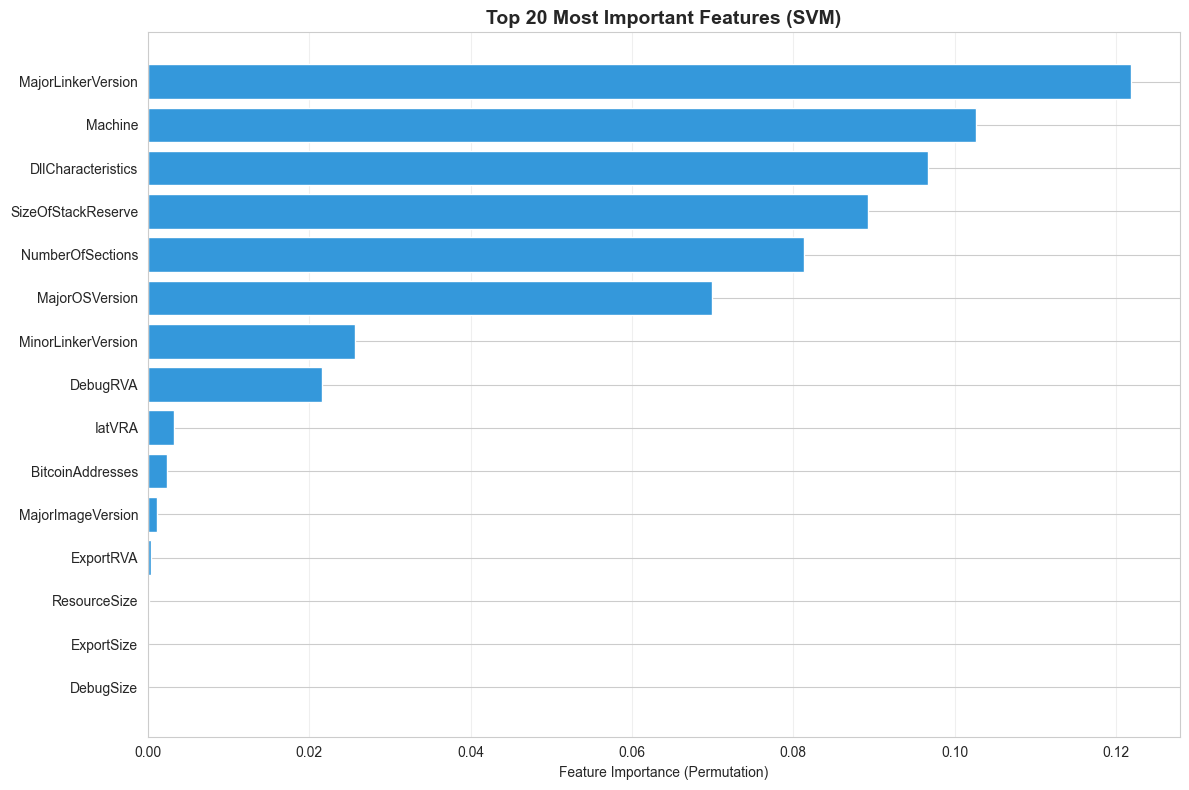

In [14]:
# Permutation Importance for SVM (Random Forest has native importance)
print("🔺 Calculating Permutation Importance for SVM (this may take a minute)...")
start_time = time.time()

perm_importance = permutation_importance(
    svm_model, X_test_scaled, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

svm_feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': perm_importance.importances_mean
}).sort_values('importance', ascending=False)

perm_time = time.time() - start_time
print(f"✅ Permutation importance calculated in {perm_time:.2f} seconds")
print(f"\n🔺 Top 20 Important Features (SVM):")
print(svm_feature_importance.head(20).to_string(index=False))

# Visualize SVM feature importance
plt.figure(figsize=(12, 8))
top_features_svm = svm_feature_importance.head(20)
plt.barh(range(len(top_features_svm)), top_features_svm['importance'], color='#3498db')
plt.yticks(range(len(top_features_svm)), top_features_svm['feature'])
plt.xlabel('Feature Importance (Permutation)')
plt.title('Top 20 Most Important Features (SVM)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 10. ROC Curves


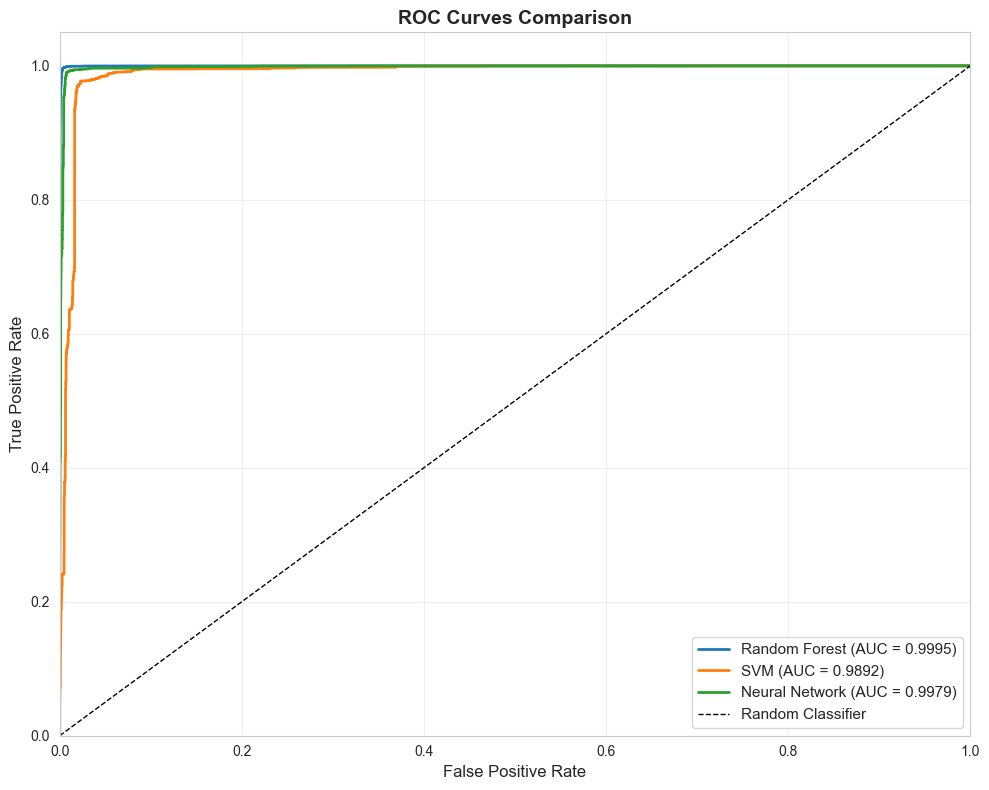

In [15]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

models_roc = [
    ('Random Forest', y_pred_proba_rf),
    ('SVM', y_pred_proba_svm),
    ('Neural Network', y_pred_proba_nn)
]

for model_name, y_pred_proba in models_roc:
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Make Predictions


In [16]:
# Example: Make predictions on test samples
def predict_sample(model, scaler, features_dict, model_name="Model"):
    """Make prediction on a single sample"""
    # Create feature array
    values = [features_dict.get(col, 0) for col in feature_columns]
    arr = np.array(values).reshape(1, -1)
    arr_scaled = scaler.transform(arr)
    
    # Predict
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(arr_scaled)[0]
        pred = model.predict(arr_scaled)[0]
    else:
        # For Keras models
        prob_output = model.predict(arr_scaled, verbose=0)
        proba = np.array([1.0 - prob_output[0][0], prob_output[0][0]])
        pred = int(prob_output[0][0] >= 0.5)
    
    result = {
        'prediction': 'Ransomware' if pred == 1 else 'Benign',
        'confidence': float(max(proba)),
        'benign_probability': float(proba[0]),
        'ransomware_probability': float(proba[1]),
        'model': model_name
    }
    
    return result

# Test on a random sample from test set
sample_idx = np.random.randint(0, len(X_test))
sample_features = X_test.iloc[sample_idx].to_dict()
true_label = 'Ransomware' if y_test.iloc[sample_idx] == 1 else 'Benign'

print(f"📊 Testing on Sample {sample_idx}:")
print(f"True Label: {true_label}")
print("\n" + "=" * 60)

# Predict with all models
for model, model_name in [(rf_model, 'Random Forest'), (svm_model, 'SVM'), (nn_model, 'Neural Network')]:
    result = predict_sample(model, scaler, sample_features, model_name)
    print(f"\n{model_name}:")
    print(f"  Prediction: {result['prediction']}")
    print(f"  Confidence: {result['confidence']:.4f}")
    print(f"  Benign Probability: {result['benign_probability']:.4f}")
    print(f"  Ransomware Probability: {result['ransomware_probability']:.4f}")

print("\n" + "=" * 60)


📊 Testing on Sample 10115:
True Label: Ransomware


Random Forest:
  Prediction: Ransomware
  Confidence: 1.0000
  Benign Probability: 0.0000
  Ransomware Probability: 1.0000

SVM:
  Prediction: Ransomware
  Confidence: 0.9472
  Benign Probability: 0.0528
  Ransomware Probability: 0.9472

Neural Network:
  Prediction: Ransomware
  Confidence: 0.9994
  Benign Probability: 0.0006
  Ransomware Probability: 0.9994



## 12. Save Models


In [17]:
import joblib

# Save models and scaler
print("💾 Saving models...")

joblib.dump(rf_model, 'notebook_rf_model.pkl')
print("  ✓ Random Forest model saved")

joblib.dump(svm_model, 'notebook_svm_model.pkl')
print("  ✓ SVM model saved")

joblib.dump(nn_model, 'notebook_nn_model.pkl')
print("  ✓ Neural Network model saved")

joblib.dump(scaler, 'notebook_scaler.pkl')
print("  ✓ Scaler saved")

joblib.dump(feature_columns, 'notebook_feature_columns.pkl')
print("  ✓ Feature columns saved")

print("\n✅ All models and artifacts saved successfully!")


💾 Saving models...
  ✓ Random Forest model saved
  ✓ SVM model saved
  ✓ Neural Network model saved
  ✓ Scaler saved
  ✓ Feature columns saved

✅ All models and artifacts saved successfully!


## Summary

This notebook demonstrated:
1. ✅ Data loading and exploration
2. ✅ Data preprocessing and cleaning
3. ✅ Training multiple ML models (Random Forest, SVM, Neural Network)
4. ✅ Model evaluation and comparison
5. ✅ Feature importance analysis
6. ✅ Visualizations (confusion matrices, ROC curves, feature importance)
7. ✅ Making predictions on test samples
8. ✅ Saving trained models

**Next Steps:**
- Experiment with different hyperparameters
- Try feature engineering
- Explore ensemble methods
- Deploy the best model to production
